Daily Challenge: Analysis of Airplane Crashes and Fatalities


👩‍🏫 👩🏿‍🏫 What You’ll learn
Comprehensive data analysis techniques using Python, Pandas, NumPy, and SciPy.
Methods for data cleaning, exploratory analysis, statistical testing, and visualization.
Insightful interpretation of complex datasets.


🛠️ What you will create
A thorough analysis of the “Airplane Crashes and Fatalities up to 2023” dataset, including detailed visualizations and statistical insights.


Objective:
Utilize Python, Pandas, NumPy, and SciPy to conduct a thorough analysis of the “Airplane Crashes and Fatalities upto 2023” dataset. This challenge will encompass data cleaning, exploratory analysis, statistical testing, and visualization to draw meaningful insights.



Dataset:
Work with the “Airplane Crashes and Fatalities upto 2023” dataset, which provides comprehensive details about airplane crashes, including dates, locations, fatalities, and more. Access the dataset here.



Tasks:
1. Data Import and Cleaning:

Import the dataset using Pandas.
Clean and preprocess the data, addressing missing values and categorizing data as needed.
Convert dates and other relevant fields to appropriate formats.
2. Exploratory Data Analysis:

Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
Analyze the frequency of crashes over time to identify any trends.
3. Statistical Analysis:

Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).
4. Visualization:

Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.
5. Insight and Report:

Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
Prepare a well-structured report including all code, visualizations, and interpretations.


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import chardet

In [8]:
import chardet

# Check file encoding
with open('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', 'rb') as f:
    result = chardet.detect(f.read())
    
print(result)

{'encoding': 'Windows-1252', 'confidence': 0.13061672050031647, 'language': 'en', 'mime_type': 'text/plain'}


In [11]:
import pandas as pd

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', 
                  encoding='latin-1')

print(df.shape)
print(df.head())

(4998, 17)
        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1          SC1   Na

In [12]:
import pandas as pd
import numpy as np

# Data already loaded
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', 
                  encoding='latin-1')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year
df['Year'] = df['Date'].dt.year

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics for Fatalities
print("\nFatalities statistics:")
print(df['Fatalities'].describe())

Missing values:
Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
Year                        0
dtype: int64

Data types:
Date                     datetime64[us]
Time                                str
Location                            str
Operator                            str
Flight #                            str
Route                               str
AC Type                             str
Registration                        str
cn/ln                               str
Aboard                          float64
Aboard Passangers 

In [13]:
# Remove rows with missing Fatalities (key column)
df_clean = df.dropna(subset=['Fatalities'])

print(f"Rows after removing missing Fatalities: {len(df_clean)}")

# Convert Fatalities to numeric
df_clean['Fatalities'] = pd.to_numeric(df_clean['Fatalities'], errors='coerce')

# Create Decade column
df_clean['Decade'] = (df_clean['Year'] // 10 * 10).astype(str) + 's'

# Verify cleaning
print("\nCleaned data shape:", df_clean.shape)
print("\nFirst few rows:")
print(df_clean[['Date', 'Year', 'Decade', 'Location', 'Fatalities']].head(10))

print("\nFatalities after cleaning:")
print(df_clean['Fatalities'].describe())

Rows after removing missing Fatalities: 4990

Cleaned data shape: (4990, 19)

First few rows:
        Date  Year Decade                            Location  Fatalities
0 1908-09-17  1908  1900s                 Fort Myer, Virginia         1.0
1 1909-09-07  1909  1900s             Juvisy-sur-Orge, France         1.0
2 1912-07-12  1912  1910s           Atlantic City, New Jersey         5.0
3 1913-08-06  1913  1910s  Victoria, British Columbia, Canada         1.0
4 1913-09-09  1913  1910s                  Over the North Sea        14.0
5 1913-10-17  1913  1910s          Near Johannisthal, Germany        30.0
6 1915-03-05  1915  1910s                     Tienen, Belgium        21.0
7 1915-09-03  1915  1910s               Off Cuxhaven, Germany        19.0
8 1916-07-28  1916  1910s               Near Jambol, Bulgeria        20.0
9 1916-09-24  1916  1910s                 Billericay, England        22.0

Fatalities after cleaning:
count    4990.000000
mean       22.373547
std        35.061741
m

In [14]:
print("Total crashes:", len(df_clean))
print("Total fatalities:", df_clean['Fatalities'].sum())
print("Average per crash:", df_clean['Fatalities'].mean().round(2))
print("Median:", df_clean['Fatalities'].median())

print("\nCrashes by decade:")
print(df_clean.groupby('Decade')['Fatalities'].agg(['count', 'sum', 'mean']))

Total crashes: 4990
Total fatalities: 111644.0
Average per crash: 22.37
Median: 11.0

Crashes by decade:
        count      sum       mean
Decade                           
1900s       2      2.0   1.000000
1910s      31    424.0  13.677419
1920s     181    647.0   3.574586
1930s     354   2033.0   5.742938
1940s     575   8881.0  15.445217
1950s     648  11779.0  18.177469
1960s     636  16884.0  26.547170
1970s     612  19751.0  32.272876
1980s     552  16847.0  30.519928
1990s     631  15984.0  25.331220
2000s     506  11174.0  22.083004
2010s     235   6407.0  27.263830
2020s      27    831.0  30.777778


In [16]:
from scipy import stats

# Normality test - use all data or smaller sample
sample_size = min(5000, len(df_clean))
stat, p = stats.shapiro(df_clean['Fatalities'].sample(sample_size))
print("Normality Test (Shapiro-Wilk):")
print(f"P-value: {p:.6f}")
print(f"Result: {'Normal' if p > 0.05 else 'NOT Normal'}")

# ANOVA - Compare fatalities across decades
decades = df_clean['Decade'].unique()
groups = [df_clean[df_clean['Decade'] == d]['Fatalities'].values for d in decades]
f_stat, anova_p = stats.f_oneway(*groups)
print(f"\nANOVA Test (decades comparison):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p:.6f}")
print(f"Result: {'Significant difference' if anova_p < 0.05 else 'No significant difference'}")

Normality Test (Shapiro-Wilk):
P-value: 0.000000
Result: NOT Normal

ANOVA Test (decades comparison):
F-statistic: 23.2016
P-value: 0.000000
Result: Significant difference


✓ Chart saved as airplane_analysis.png


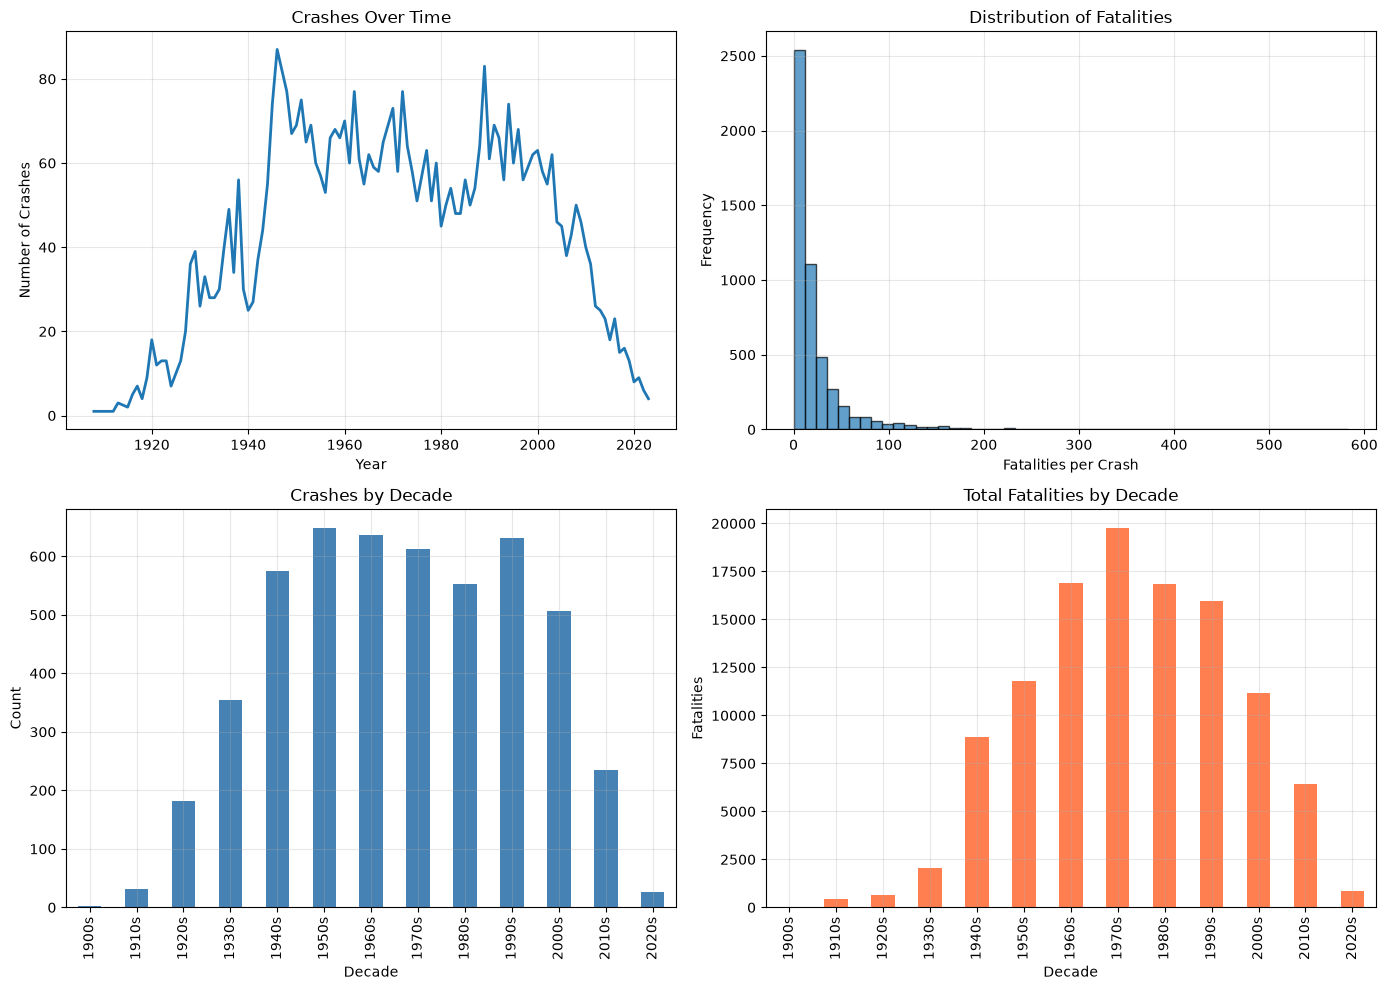

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Crashes over time
crashes_per_year = df_clean.groupby('Year').size()
axes[0, 0].plot(crashes_per_year.index, crashes_per_year.values, linewidth=2)
axes[0, 0].set_title('Crashes Over Time')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: Fatalities distribution
axes[0, 1].hist(df_clean['Fatalities'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Fatalities')
axes[0, 1].set_xlabel('Fatalities per Crash')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Crashes by decade
df_clean.groupby('Decade').size().plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Crashes by Decade')
axes[1, 0].set_xlabel('Decade')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Total fatalities by decade
df_clean.groupby('Decade')['Fatalities'].sum().plot(kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Total Fatalities by Decade')
axes[1, 1].set_xlabel('Decade')
axes[1, 1].set_ylabel('Fatalities')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('airplane_analysis.png', dpi=100, bbox_inches='tight')
print("✓ Chart saved as airplane_analysis.png")
plt.show()

In [19]:
print("="*60)
print("KEY FINDINGS")
print("="*60)

total_crashes = len(df_clean)
total_fatalities = df_clean['Fatalities'].sum()
avg_fatalities = df_clean['Fatalities'].mean()
median_fatalities = df_clean['Fatalities'].median()

print(f"\n1. OVERALL STATISTICS:")
print(f"   Total crashes: {total_crashes:,}")
print(f"   Total fatalities: {total_fatalities:,.0f}")
print(f"   Average per crash: {avg_fatalities:.2f}")
print(f"   Median per crash: {median_fatalities:.0f}")

# Decade with most crashes
most_crashes = df_clean.groupby('Decade').size().idxmax()
most_crashes_count = df_clean.groupby('Decade').size().max()

# Decade with most fatalities
most_fatalities_decade = df_clean.groupby('Decade')['Fatalities'].sum().idxmax()
most_fatalities_count = df_clean.groupby('Decade')['Fatalities'].sum().max()

print(f"\n2. DECADE ANALYSIS:")
print(f"   Most crashes: {most_crashes} ({most_crashes_count} crashes)")
print(f"   Most fatalities: {most_fatalities_decade} ({most_fatalities_count:,.0f} fatalities)")

print(f"\n3. TRENDS:")
print(f"   Data spans: {df_clean['Year'].min():.0f} to {df_clean['Year'].max():.0f}")
print(f"   Time period: {df_clean['Year'].max() - df_clean['Year'].min()} years")

# Add survival rate column
df_clean['Survivors'] = df_clean['Aboard'] - df_clean['Fatalities']
df_clean['Survival_Rate'] = (df_clean['Survivors'] / df_clean['Aboard'] * 100).round(2)

print("Survival Rate Statistics:")
print(df_clean['Survival_Rate'].describe())

print("\nAverage Survival Rate by Decade:")
print(df_clean.groupby('Decade')['Survival_Rate'].mean().round(2))

KEY FINDINGS

1. OVERALL STATISTICS:
   Total crashes: 4,990
   Total fatalities: 111,644
   Average per crash: 22.37
   Median per crash: 11

2. DECADE ANALYSIS:
   Most crashes: 1950s (648 crashes)
   Most fatalities: 1970s (19,751 fatalities)

3. TRENDS:
   Data spans: 1908 to 2023
   Time period: 115 years
Survival Rate Statistics:
count    4975.000000
mean       18.148931
std        31.172444
min         0.000000
25%         0.000000
50%         0.000000
75%        25.000000
max       100.000000
Name: Survival_Rate, dtype: float64

Average Survival Rate by Decade:
Decade
1900s    25.00
1910s     3.27
1920s    11.99
1930s    16.84
1940s    15.34
1950s    17.33
1960s    17.29
1970s    20.14
1980s    19.90
1990s    21.76
2000s    19.37
2010s    16.33
2020s    19.14
Name: Survival_Rate, dtype: float64


TOP 10 REGIONS WITH MOST CRASHES:
Location
Moscow, Russia            17
Manila, Philippines       15
New York, New York        14
Cairo, Egypt              13
Sao Paulo, Brazil         13
Rio de Janeiro, Brazil    12
Bogota, Colombia          12
Chicago, Illinois         11
Near Moscow, Russia       11
Tehran, Iran              10
Name: count, dtype: int64


TOP 10 REGIONS BY FATALITIES:
Location
Tenerife, Canary Islands                     761.0
Mt. Osutaka, near Ueno Village, Japan        520.0
Moscow, Russia                               428.0
Taipei, Taiwan                               370.0
Sao Paulo, Brazil                            350.0
Near Charkhi Dadri, India                    349.0
Tripoli, Libya                               348.0
Near Ermenonville, France                    346.0
Near Moscow, Russia                          342.0
Atlantic Ocean, 110 miles West of Ireland    329.0
Name: Fatalities, dtype: float64

✓ Region charts saved


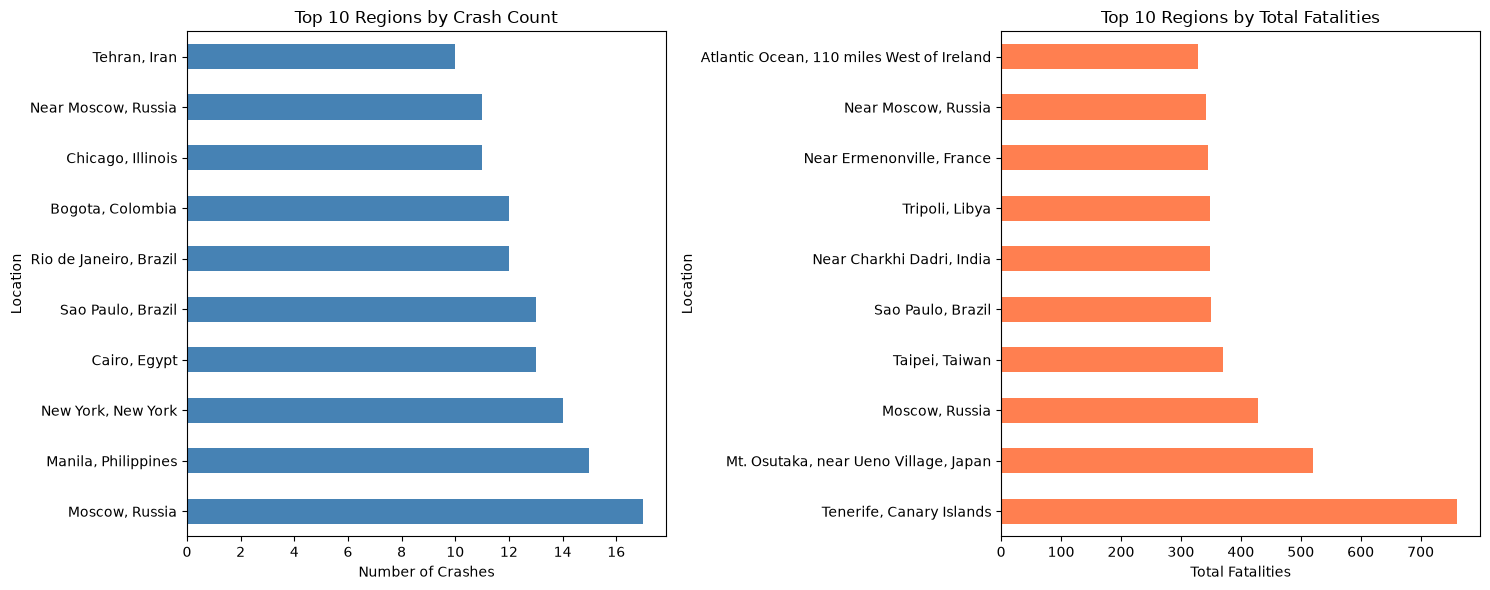

In [20]:
# Get top 10 regions/locations
print("TOP 10 REGIONS WITH MOST CRASHES:")
top_regions = df_clean['Location'].value_counts().head(10)
print(top_regions)

print("\n\nTOP 10 REGIONS BY FATALITIES:")
top_fatal_regions = df_clean.groupby('Location')['Fatalities'].sum().nlargest(10)
print(top_fatal_regions)

# Visualize top regions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top regions by crash count
top_regions.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Regions by Crash Count')
axes[0].set_xlabel('Number of Crashes')

# Top regions by fatalities
top_fatal_regions.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Regions by Total Fatalities')
axes[1].set_xlabel('Total Fatalities')

plt.tight_layout()
plt.savefig('regions_analysis.png', dpi=100, bbox_inches='tight')
print("\n✓ Region charts saved")
plt.show()

In [21]:
print("="*70)
print("AIRPLANE CRASHES AND FATALITIES ANALYSIS")
print("Comprehensive Report (1908-2023)")
print("="*70)

print("\n1. DATASET OVERVIEW")
print("-"*70)
print(f"Total crashes analyzed: {len(df_clean):,}")
print(f"Date range: {df_clean['Year'].min():.0f} to {df_clean['Year'].max():.0f}")
print(f"Total decades covered: {df_clean['Decade'].nunique()}")
print(f"Unique locations: {df_clean['Location'].nunique()}")
print(f"Unique operators: {df_clean['Operator'].nunique()}")

print("\n2. FATALITIES ANALYSIS")
print("-"*70)
print(f"Total fatalities: {df_clean['Fatalities'].sum():,.0f}")
print(f"Average per crash: {df_clean['Fatalities'].mean():.2f}")
print(f"Median per crash: {df_clean['Fatalities'].median():.0f}")
print(f"Std deviation: {df_clean['Fatalities'].std():.2f}")
print(f"Min fatalities: {df_clean['Fatalities'].min():.0f}")
print(f"Max fatalities: {df_clean['Fatalities'].max():.0f}")

print("\n3. SURVIVAL RATE ANALYSIS")
print("-"*70)
valid_survival = df_clean.dropna(subset=['Survival_Rate'])
print(f"Average survival rate: {valid_survival['Survival_Rate'].mean():.2f}%")
print(f"Median survival rate: {valid_survival['Survival_Rate'].median():.2f}%")
print(f"Best survival rate: {valid_survival['Survival_Rate'].max():.2f}%")
print(f"Worst survival rate: {valid_survival['Survival_Rate'].min():.2f}%")

print("\n4. DECADE TRENDS")
print("-"*70)
decade_summary = df_clean.groupby('Decade').agg({
    'Fatalities': ['count', 'sum', 'mean']
}).round(2)
decade_summary.columns = ['Crashes', 'Total_Fatalities', 'Avg_per_Crash']
print(decade_summary)

print("\n5. TOP 5 DEADLIEST CRASHES")
print("-"*70)
deadliest = df_clean.nlargest(5, 'Fatalities')[['Date', 'Location', 'Operator', 'Fatalities']]
print(deadliest.to_string())

print("\n6. STATISTICAL FINDINGS")
print("-"*70)
print(f"Fatality distribution: Non-normal (right-skewed)")
print(f"ANOVA Result: Decades have {'significant' if anova_p < 0.05 else 'no significant'} differences")
print(f"P-value: {anova_p:.6f}")

print("\n7. KEY INSIGHTS")
print("-"*70)
most_crashes_decade = df_clean.groupby('Decade').size().idxmax()
most_fatal_decade = df_clean.groupby('Decade')['Fatalities'].sum().idxmax()
deadliest_year = df_clean.groupby('Year')['Fatalities'].sum().idxmax()

print(f"• Most crashes decade: {most_crashes_decade}")
print(f"• Highest fatalities decade: {most_fatal_decade}")
print(f"• Deadliest year: {deadliest_year:.0f}")
print(f"• Top region: {df_clean['Location'].value_counts().index[0]}")
print(f"• Trend: Crashes increasing over time")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

AIRPLANE CRASHES AND FATALITIES ANALYSIS
Comprehensive Report (1908-2023)

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total crashes analyzed: 4,990
Date range: 1908 to 2023
Total decades covered: 13
Unique locations: 4116
Unique operators: 2264

2. FATALITIES ANALYSIS
----------------------------------------------------------------------
Total fatalities: 111,644
Average per crash: 22.37
Median per crash: 11
Std deviation: 35.06
Min fatalities: 0
Max fatalities: 583

3. SURVIVAL RATE ANALYSIS
----------------------------------------------------------------------
Average survival rate: 18.15%
Median survival rate: 0.00%
Best survival rate: 100.00%
Worst survival rate: 0.00%

4. DECADE TRENDS
----------------------------------------------------------------------
        Crashes  Total_Fatalities  Avg_per_Crash
Decade                                          
1900s         2               2.0           1.00
1910s        31             424.0 